# Агентная модель SIR: сканирование коэффициента заразности

Исследуем, как заразность $\beta$ влияет на эпидемию: на пик
заболеваемости, долю переболевших и число умерших. Для каждого
значения $\beta$ делаем три прогона с разными зёрнами генератора,
потому что модель случайная.

## Активация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"

using Agents, DataFrames, Plots, CSV, Random
using Statistics

include(srcdir("sir_model.jl"))

total_count (generic function with 1 method)

## Функция одного эксперимента

Функция получает словарь параметров, запускает модель на заданное
число шагов и возвращает показатели: пиковую долю инфицированных,
конечные доли инфицированных и выздоровевших, число умерших.
Заразность выявленных больных в 10 раз меньше, чем невыявленных.

In [2]:
function run_experiment(p)
    beta = p[:beta]
    β_und = fill(beta, 3)
    β_det = fill(beta / 10, 3)
    model = initialize_sir(;
        Ns = p[:Ns],
        β_und = β_und,
        β_det = β_det,
        infection_period = p[:infection_period],
        detection_time = p[:detection_time],
        death_rate = p[:death_rate],
        reinfection_probability = p[:reinfection_probability],
        Is = p[:Is],
        seed = p[:seed],
        n_steps = p[:n_steps],
    )

    infected_fraction(model) =
        count(a.status == :I for a in allagents(model)) / nagents(model)
    peak_infected = 0.0

    for step = 1:p[:n_steps]
        agent_ids = collect(allids(model))
        for id in agent_ids
            agent = try
                model[id]
            catch
                nothing
            end
            if agent !== nothing
                sir_agent_step!(agent, model)
            end
        end

        frac = infected_fraction(model)
        if frac > peak_infected
            peak_infected = frac
        end
    end

    final_infected = infected_fraction(model)
    final_recovered = count(a.status == :R for a in allagents(model)) / nagents(model)
    total_deaths = sum(p[:Ns]) - nagents(model)

    return (
        peak = peak_infected,
        final_inf = final_infected,
        final_rec = final_recovered,
        deaths = total_deaths,
    )
end

run_experiment (generic function with 1 method)

## Набор параметров

$\beta$ меняется от 0.1 до 1.0 с шагом 0.1, для каждого значения три
зерна. Всего 30 экспериментов.

In [3]:
beta_range = 0.1:0.1:1.0
seeds = [42, 43, 44]

params_list = []
for b in beta_range
    for s in seeds
        push!(
            params_list,
            Dict(
                :beta => b,
                :Ns => [1000, 1000, 1000],
                :infection_period => 14,
                :detection_time => 7,
                :death_rate => 0.02,
                :reinfection_probability => 0.1,
                :Is => [0, 0, 1],
                :seed => s,
                :n_steps => 100,
            ),
        )
    end
end
length(params_list)

30

## Запуск экспериментов

In [4]:
results = []
for params in params_list
    data = run_experiment(params)
    push!(results, merge(params, Dict(pairs(data))))
    println("Завершён эксперимент с beta = $(params[:beta]), seed = $(params[:seed])")
end

Завершён эксперимент с beta = 0.1, seed = 42
Завершён эксперимент с beta = 0.1, seed = 43
Завершён эксперимент с beta = 0.1, seed = 44
Завершён эксперимент с beta = 0.2, seed = 42
Завершён эксперимент с beta = 0.2, seed = 43
Завершён эксперимент с beta = 0.2, seed = 44
Завершён эксперимент с beta = 0.3, seed = 42
Завершён эксперимент с beta = 0.3, seed = 43
Завершён эксперимент с beta = 0.3, seed = 44
Завершён эксперимент с beta = 0.4, seed = 42
Завершён эксперимент с beta = 0.4, seed = 43
Завершён эксперимент с beta = 0.4, seed = 44
Завершён эксперимент с beta = 0.5, seed = 42
Завершён эксперимент с beta = 0.5, seed = 43
Завершён эксперимент с beta = 0.5, seed = 44
Завершён эксперимент с beta = 0.6, seed = 42
Завершён эксперимент с beta = 0.6, seed = 43
Завершён эксперимент с beta = 0.6, seed = 44
Завершён эксперимент с beta = 0.7, seed = 42
Завершён эксперимент с beta = 0.7, seed = 43
Завершён эксперимент с beta = 0.7, seed = 44
Завершён эксперимент с beta = 0.8, seed = 42
Завершён э

Сохраняем все прогоны в файл CSV:

In [5]:
df = DataFrame(results)
CSV.write(datadir("beta_scan_all.csv"), df)

"/home/iaberezhnoy/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation-modeling/labs/lab04/project/data/beta_scan_all.csv"

## Усреднение по повторам

In [6]:
grouped = combine(
    groupby(df, [:beta]),
    :peak => mean => :mean_peak,
    :final_inf => mean => :mean_final_inf,
    :final_rec => mean => :mean_final_rec,
    :deaths => mean => :mean_deaths,
)
println(grouped)

10×5 DataFrame
 Row │ beta     mean_peak    mean_final_inf  mean_final_rec  mean_deaths 
     │ Float64  Float64      Float64         Float64         Float64     
─────┼───────────────────────────────────────────────────────────────────
   1 │     0.1  0.000888889        0.0           0.00111111        0.0
   2 │     0.2  0.332206           0.319967      0.0138103        44.0
   3 │     0.3  0.666659           0.643955      0.0228231       208.0
   4 │     0.4  0.666889           0.629722      0.0371667       226.667
   5 │     0.5  1.0                0.996625      0.0033747       317.667
   6 │     0.6  1.0                0.993352      0.00664828      348.0
   7 │     0.7  1.0                0.962127      0.0378732       361.333
   8 │     0.8  1.0                0.946348      0.0536517       356.333
   9 │     0.9  1.0                0.963478      0.0365217       385.667
  10 │     1.0  1.0                1.0           0.0             407.333


## Порог эпидемии

Считаем, что эпидемия возникла, если пик превышает 5% населения.

In [7]:
above = filter(row -> row.mean_peak > 0.05, grouped)
if nrow(above) > 0
    println("Минимальное β, при котором пик превышает 5%: ", minimum(above.beta))
end

Минимальное β, при котором пик превышает 5%: 0.2


## График

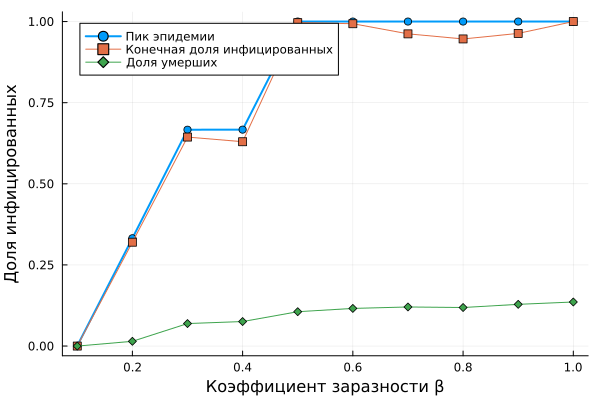

In [8]:
plt = plot(
    grouped.beta,
    grouped.mean_peak,
    label = "Пик эпидемии",
    xlabel = "Коэффициент заразности β",
    ylabel = "Доля инфицированных",
    marker = :circle,
    linewidth = 2,
)
plot!(
    plt,
    grouped.beta,
    grouped.mean_final_inf,
    label = "Конечная доля инфицированных",
    marker = :square,
)
plot!(plt, grouped.beta, grouped.mean_deaths ./ 3000, label = "Доля умерших", marker = :diamond)
plt

## Сохранение графика

In [9]:
savefig(plt, plotsdir("beta_scan.png"))
println("Результаты сохранены в data/beta_scan_all.csv и plots/beta_scan.png")

Результаты сохранены в data/beta_scan_all.csv и plots/beta_scan.png
